# Lensing growth factor $D_L(z)$

In cosmology, gravitational lensing of light from distant galaxies depends on the **growth of structure** and the **geometry of the Universe**.

We define the growth factor of lensing $D_L(z)$, used in weak lensing observables such as the convergence power spectrum.

This notebook derives and evaluates:

$
D_L(z) = \frac{3}{2} \Omega_m \int_0^z dz' \, \frac{D(z')}{E(z')} \cdot \frac{x(z') \left[ x(z) - x(z') \right]}{x(z)} (1 + z')$

where:
- $\Omega_m$ is the matter density today,
- $x(z)$ is the transverse comoving distance,
- $E(z) = H(z)/H_0$ is the normalized Hubble rate,
- $D(z)$ is the linear growth factor normalized to $D(0) = 1$.


In [252]:
# general imports
import numpy as np
from scipy.integrate import quad
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# astropy imports
from astropy.cosmology import Planck18 as cosmo
# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations


Solve using `cloelib` quantities and numerical integration

In [ ]:
# The arguments of the Background functions follow the cosmology.API
# We use Planck18 cosmology as a reference using astropy
z_vals = np.linspace(0.01, 100, 100)
background = CAMBBackground(H0=cosmo.H0.value, 
                            Omega_cdm0=(cosmo.Om0 - cosmo.Ob0), 
                            Omega_b0=cosmo.Ob0, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, z_vals)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, z_vals, log10TAGN=7.8)

In [254]:
# Re-evaluate the intagrand using CAMB and HMcode
def D_L_integrand_cloelib(zp, z):
    c = 3e5
    d_h = c/background.H0
    x_z = background.transverse_comoving_distance(z)/d_h
    x_zp = background.transverse_comoving_distance(zp)/d_h
    x_zp_z = x_z - x_zp
    if x_zp_z < 0:
        return 0
    D_zp = linear_perturbations_emu.growth_factor(zp, 0.01) #fix k-dependency
    E_zp = background.hubble_parameter(zp)/background.hubble_parameter(0)
    return D_zp * x_zp * x_zp_z / x_z * (1 + zp) / E_zp

# Lensing efficiency D_L(z)
def D_L_cloelib(z):
    Omega_m = background.Omega_m(0)
    integral, _ = quad(D_L_integrand_cloelib, 0, z, args=(z,))
    return 1.5 * Omega_m * integral #* background.hubble_parameter(0)/ 3e5

In [ ]:
# Evaluate
D_L_vals_cloelib = [D_L_cloelib(z) for z in z_vals]

/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_78070/2106232347.py:17: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(D_L_integrand_cloelib, 0, z, args=(z,))
/var/folders/y3/rj7198150gd4ch0bpxf3v2csrg24w5/T/ipykernel_78070/2106232347.py:17: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, _ = quad(D_L_integrand_cloelib, 0, z, args=(z,))


### Plot quantities and final result

In [245]:
colors = {
    'cloelib': 'cornflowerblue',
}

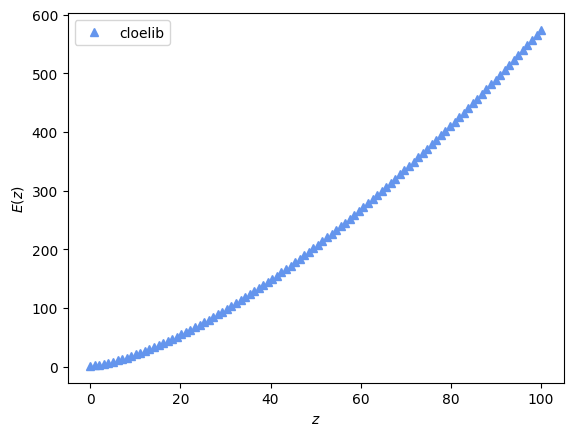

In [246]:
plt.plot(z_vals, background.hubble_parameter(z_vals)/background.hubble_parameter(0), '^', label='cloelib', color=colors['cloelib'])
plt.xlabel('$z$')
plt.ylabel(r'$E(z)$')
plt.legend();

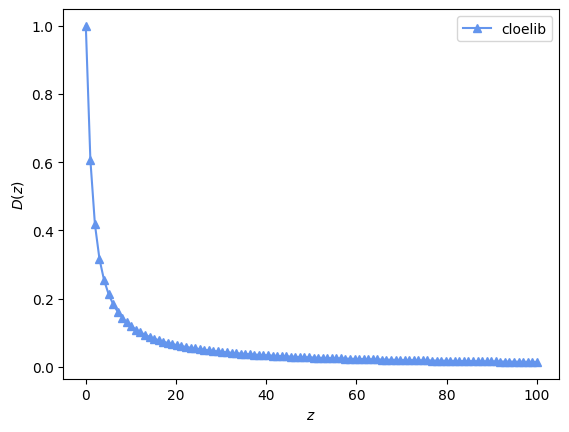

In [250]:
plt.plot(z_vals, nonlinear_perturbations_emu.growth_factor(z_vals, 0.01), '^-', label='cloelib', color=colors['cloelib'])
plt.xlabel('$z$')
plt.ylabel(r'$D(z)$')
plt.legend();

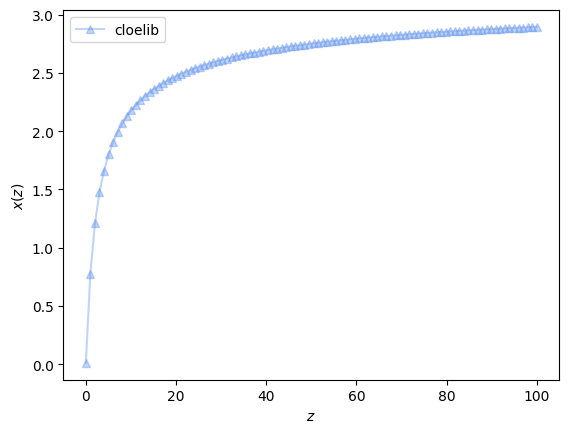

In [251]:
plt.plot(z_vals, background.transverse_comoving_distance(z_vals)/d_h, '^-', label='cloelib', color=colors['cloelib'], alpha=0.4)
plt.xlabel('$z$')
plt.ylabel(r'$x(z)$')
plt.legend();

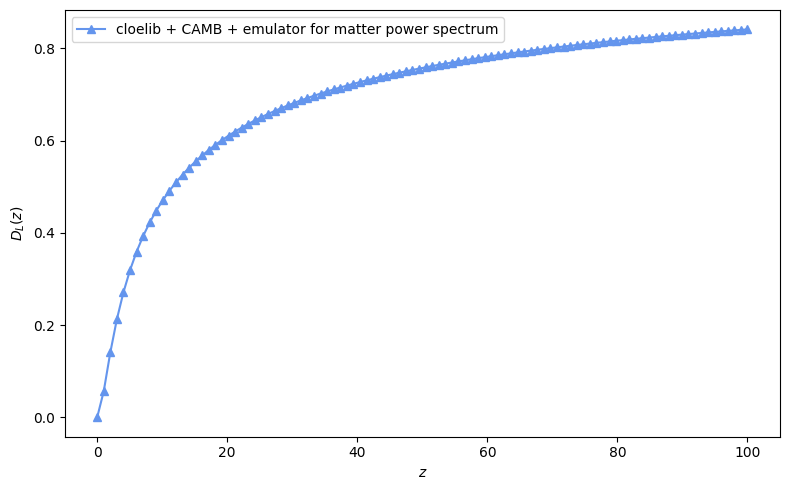

In [249]:
plt.figure(figsize=(8, 5))
plt.plot(z_vals, D_L_vals_cloelib, '^-', label='cloelib + CAMB + emulator for matter power spectrum', color=colors['cloelib'])
plt.xlabel('$z$')
plt.ylabel(r'$D_L(z)$')
plt.tight_layout()
plt.legend();

This integral converges to 1 when $z \rightarrow \infty$. Why? This integral represents the _lensing efficiency_. At $z \rightarrow \infty$, all cosmic structure has already been formed, and therefore, in the line of sight, the lensing growth takes its maximum value. At this point, all structure between us and the sources contributes to lensing. Because in cosmology we usually take the linear matter growth $D(z)$ to be normalised, $D_L(z)$ is normalised by construction.